In [1]:
#Cau1
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()
print(data.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

             Số lượng thiếu  Tỷ lệ thiếu (%)
PassengerId               0         0.000000
Survived                  0         0.000000
Pclass                    0         0.000000
Name                      0         0.000000
Sex                       0         0.000000
Age                     177        19.865320
SibSp                     0         0.000000
Parch                     0         0.000000
Ticket                    0         0.000000
Fare                      0         0.000000
Cabin                   687        77.104377
Embarked                  2         0.224467


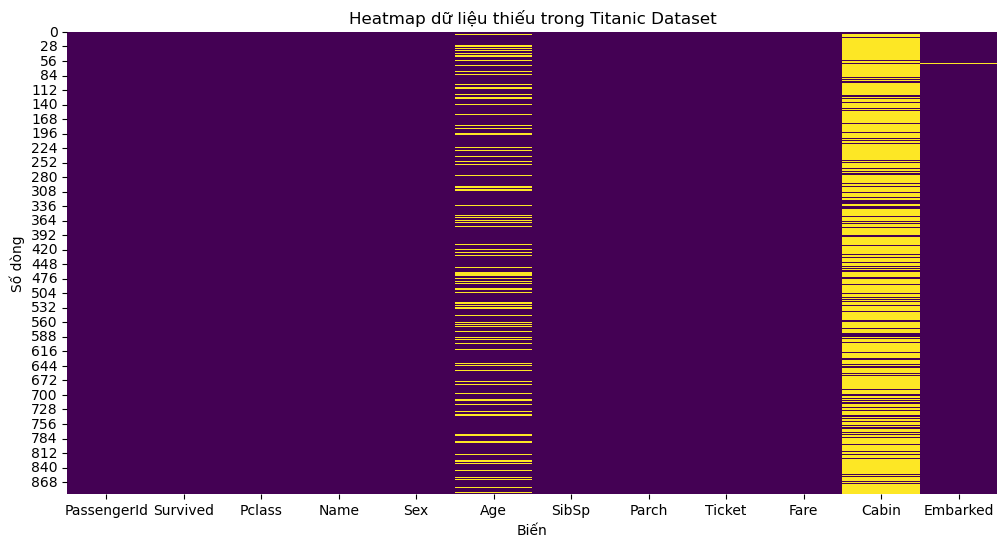

In [2]:
#Cau2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

missing_count = data.isnull().sum()
missing_percent = data.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Số lượng thiếu": missing_count,
    "Tỷ lệ thiếu (%)": missing_percent
})

print(missing_df)

plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap dữ liệu thiếu trong Titanic Dataset")
plt.xlabel("Biến")
plt.ylabel("Số dòng")
plt.show()



In [3]:
#Cau3
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["firstName"] = data["Name"].str.split(",").str[0]
data["secondName"] = data["Name"].str.split(",").str[1].str.split(".").str[1].str.strip()

data.drop(columns=["Name"], inplace=True)

print(data[["firstName", "secondName"]].head())


   firstName                             secondName
0     Braund                            Owen Harris
1    Cumings  John Bradley (Florence Briggs Thayer)
2  Heikkinen                                  Laina
3   Futrelle          Jacques Heath (Lily May Peel)
4      Allen                          William Henry


In [4]:
#Cau4
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["Sex"] = data["Sex"].replace({
    "male": "M",
    "female": "F"
})

print(data["Sex"].value_counts())


Sex
M    577
F    314
Name: count, dtype: int64


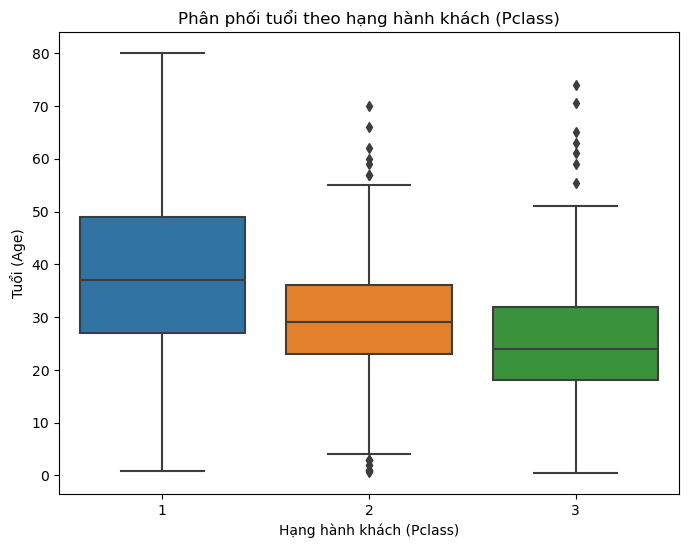

In [5]:
#Cau5 a)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

plt.figure(figsize=(8, 6))
sns.boxplot(x="Pclass", y="Age", data=data)
plt.title("Phân phối tuổi theo hạng hành khách (Pclass)")
plt.xlabel("Hạng hành khách (Pclass)")
plt.ylabel("Tuổi (Age)")
plt.show()


10 dòng đầu tiên sau khi xử lý Age:
   Pclass       Age
0       3  22.00000
1       1  38.00000
2       3  26.00000
3       1  35.00000
4       3  35.00000
5       3  25.14062
6       1  54.00000
7       3   2.00000
8       3  27.00000
9       2  14.00000

Số giá trị Age bị thiếu sau xử lý:
0


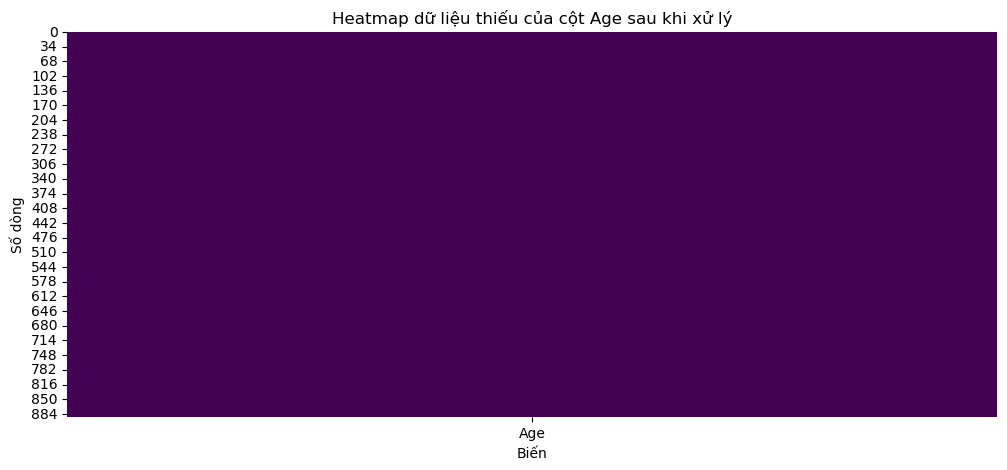

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["Age"] = data.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.mean())
)

print("10 dòng đầu tiên sau khi xử lý Age:")
print(data[["Pclass", "Age"]].head(10))

print("\nSố giá trị Age bị thiếu sau xử lý:")
print(data["Age"].isnull().sum())

plt.figure(figsize=(12, 5))
sns.heatmap(data[["Age"]].isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap dữ liệu thiếu của cột Age sau khi xử lý")
plt.xlabel("Biến")
plt.ylabel("Số dòng")
plt.show()


In [16]:
#Cau6
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["Agegroup"] = pd.cut(
    data["Age"],
    bins=[0, 12, 18, 60, float("inf")],
    labels=["Kid", "Teen", "Adult", "Older"]
)

print(data[["Age", "Agegroup"]].head(10))


    Age Agegroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult
5   NaN      NaN
6  54.0    Adult
7   2.0      Kid
8  27.0    Adult
9  14.0     Teen


In [17]:
#Cau7
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["firstName"] = data["Name"].str.split(",").str[0]
data["secondName"] = (
    data["Name"]
    .str.split(",").str[1]
    .str.strip()
)

data["namePrefix"] = data["secondName"].str.extract(r"(Mr|Mrs|Miss|Master)")

data.drop(columns=["Name"], inplace=True)

print(data[["secondName", "namePrefix"]].head(10))


                                   secondName namePrefix
0                             Mr. Owen Harris         Mr
1  Mrs. John Bradley (Florence Briggs Thayer)         Mr
2                                 Miss. Laina       Miss
3          Mrs. Jacques Heath (Lily May Peel)         Mr
4                           Mr. William Henry         Mr
5                                   Mr. James         Mr
6                               Mr. Timothy J         Mr
7                       Master. Gosta Leonard     Master
8    Mrs. Oscar W (Elisabeth Vilhelmina Berg)         Mr
9                 Mrs. Nicholas (Adele Achem)         Mr


In [18]:
#Cau8
import pandas as pd

def load_data():
    return pd.read_csv("titanic_disaster.csv")

data = load_data()

data["familySize"] = 1 + data["SibSp"] + data["Parch"]

print(data[["SibSp", "Parch", "familySize"]].head(10))


   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2
